In [62]:
import pandas as pd

In [63]:
import numpy as np

In [64]:
import matplotlib.pyplot as plt

In [65]:
import seaborn as sns

In [66]:
%matplotlib inline

In [67]:
df = pd.read_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/raw/vgchartz-2024.csv")

In [68]:
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


In [69]:
df.dtypes # check data types

img              object
title            object
console          object
genre            object
publisher        object
developer        object
critic_score    float64
total_sales     float64
na_sales        float64
jp_sales        float64
pal_sales       float64
other_sales     float64
release_date     object
last_update      object
dtype: object

In [70]:
df = df.drop(['img','last_update'], axis=1) # remove columns

In [71]:
df.head()

,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06


In [72]:
df = df.rename(columns={"title": "Game Title", "console": "Console",
                        "genre": "Genre", "publisher": "Publisher",
                        "developer": "Developer", "critic_score": "Critic Score",
                        "total_sales": "Sales", "na_sales": "North American Sales",
                        "jp_sales": "Japanese Sales", "pal_sales": "EU Sales", 
                        "other_sales": "Other Sales", "release_date": "Release Date",})  # rename columns

In [73]:
df.shape # check dimentions

(64016, 12)

In [74]:
df.count() # count rows

Game Title              64016
Console                 64016
Genre                   64016
Publisher               64016
Developer               63999
Critic Score             6678
Sales                   18922
North American Sales    12637
Japanese Sales           6726
EU Sales                12824
Other Sales             15128
Release Date            56965
dtype: int64

In [75]:
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)   #check duplicates 

number of duplicate rows:  (21, 12)


In [76]:
df = df.drop_duplicates() # drop duplicates

In [77]:
print(df.isnull().sum()) # missing values ( null )

Game Title                  0
Console                     0
Genre                       0
Publisher                   0
Developer                  17
Critic Score            57317
Sales                   45076
North American Sales    51358
Japanese Sales          57272
EU Sales                51171
Other Sales             48867
Release Date             7051
dtype: int64


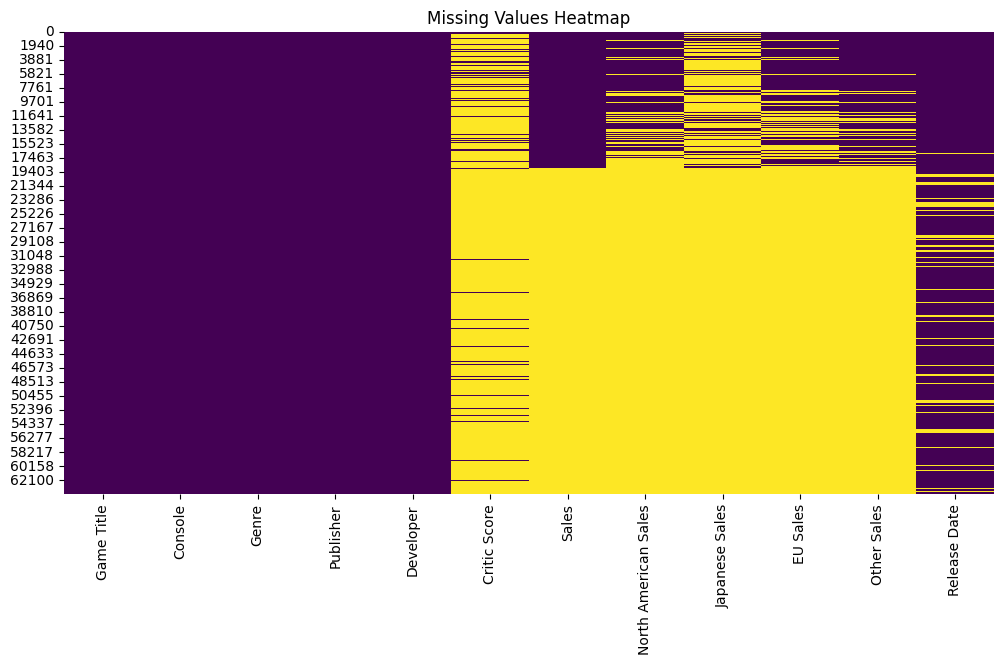

In [78]:
# Heatmap of missing values

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

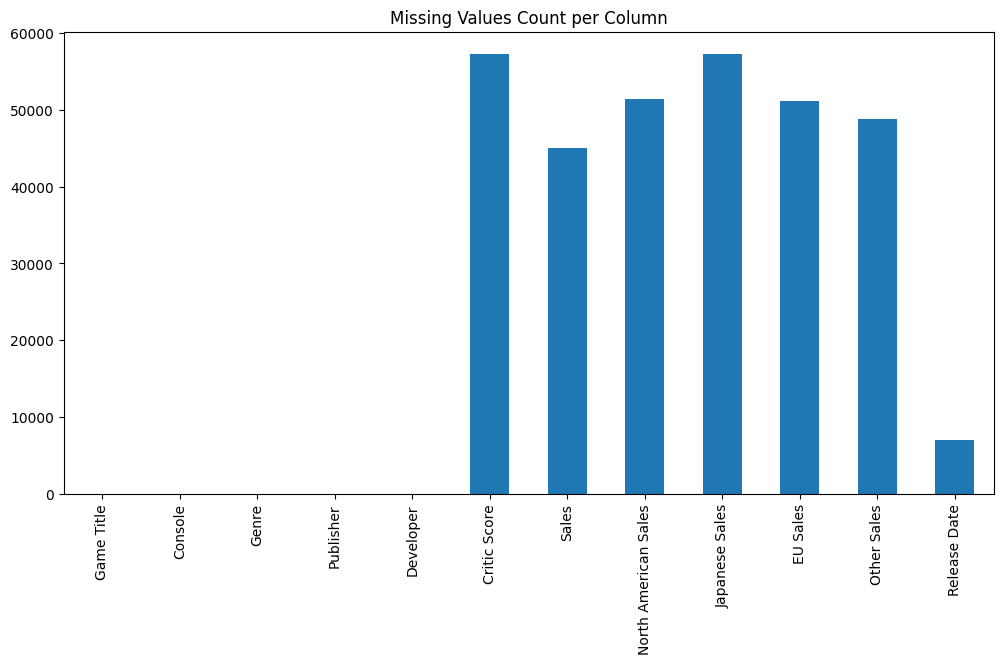

In [48]:
# Bar plot of missing values count per column
df.isnull().sum().plot(kind='bar', figsize=(12,6))
plt.title("Missing Values Count per Column")
plt.show()

In [49]:
# 1. Drop rows with missing target 
df = df.dropna(subset=['Sales'])

# 2. Fill categorical with "Unknown"
for col in ['Publisher','Developer','Genre','Console']:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

# 3. Fill regional sales with 0
for col in ['North American Sales','Japanese Sales','EU Sales','Other Sales']:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# 4. Critic Score -> fill with mean
if 'Critic Score' in df.columns:
    df['Critic Score'] = df['Critic Score'].fillna(df['Critic Score'].mean())

# 5. Release Date -> convert to year, fill missing with median
df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')
df['Release Year'] = df['Release Date'].dt.year
df['Release Year'] = df['Release Year'].fillna(df['Release Year'].median())

df = df.drop(['Release Date'], axis=1)

df["Release Year"] = df["Release Year"].astype(int)

In [50]:
df.head()

,Game Title,Console,Genre,Publisher,Developer,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.40000,20.32,6.37,0.99,9.85,3.12,2013
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.70000,19.39,6.06,0.60,9.71,3.02,2014
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.60000,16.15,8.41,0.47,5.49,1.78,2002
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.10189,15.86,9.06,0.06,5.33,1.42,2013
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.10000,15.09,6.18,0.41,6.05,2.44,2015


In [51]:
df.count() # count rows

Game Title              18919
Console                 18919
Genre                   18919
Publisher               18919
Developer               18919
Critic Score            18919
Sales                   18919
North American Sales    18919
Japanese Sales          18919
EU Sales                18919
Other Sales             18919
Release Year            18919
dtype: int64

In [52]:
# Calculate regional sum for incorrection between Sales & Regional Sales
regional_sum = (df["North American Sales"] +
    df["Japanese Sales"] +
    df["EU Sales"] +
    df["Other Sales"]
)

# Replace Sales if regional sum is greater
df.loc[regional_sum > df["Sales"], "Sales"] = regional_sum

In [53]:
df.head()

,Game Title,Console,Genre,Publisher,Developer,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.40000,20.33,6.37,0.99,9.85,3.12,2013
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.70000,19.39,6.06,0.60,9.71,3.02,2014
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.60000,16.15,8.41,0.47,5.49,1.78,2002
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.10189,15.87,9.06,0.06,5.33,1.42,2013
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.10000,15.09,6.18,0.41,6.05,2.44,2015


In [54]:
df.dtypes # check data types

Game Title               object
Console                  object
Genre                    object
Publisher                object
Developer                object
Critic Score            float64
Sales                   float64
North American Sales    float64
Japanese Sales          float64
EU Sales                float64
Other Sales             float64
Release Year              int64
dtype: object

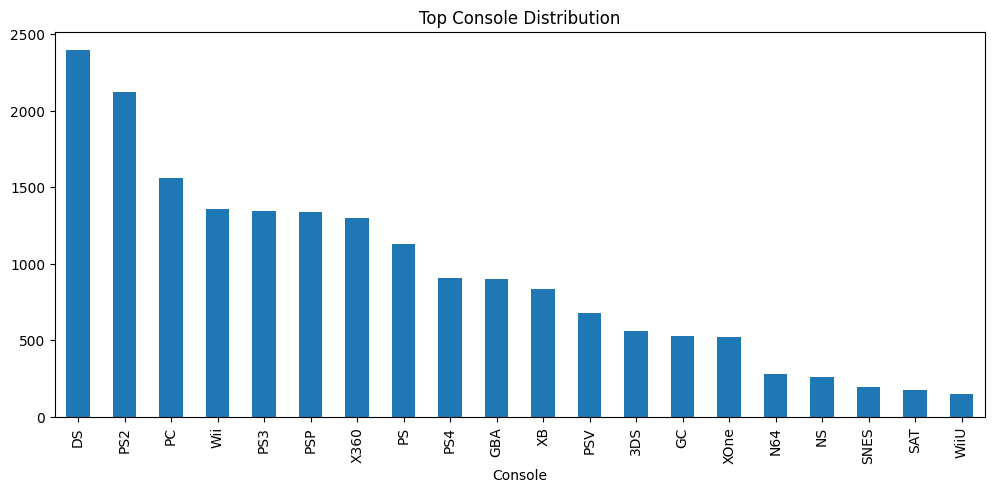

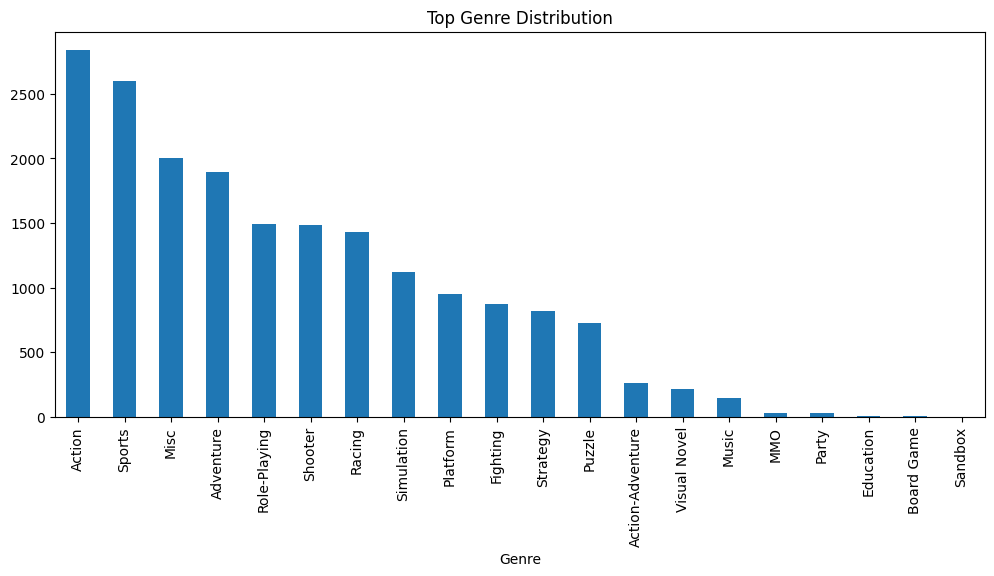

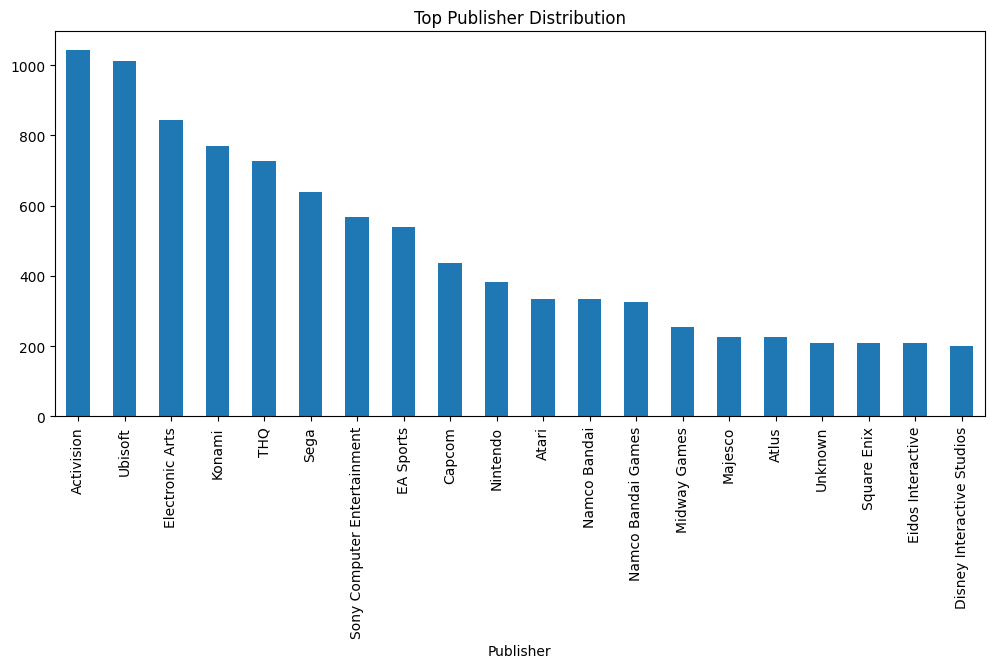

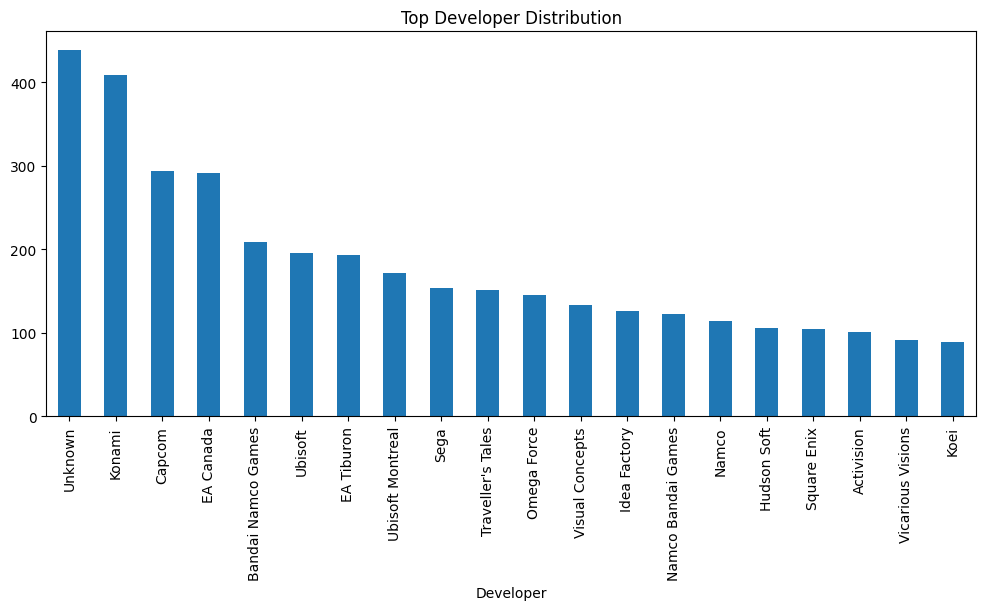

In [55]:
#Count of categorical values

for col in ["Console", "Genre", "Publisher", "Developer"]:
    plt.figure(figsize=(12,5))
    df[col].value_counts().head(20).plot(kind="bar")
    plt.title(f"Top {col} Distribution")
    plt.show()

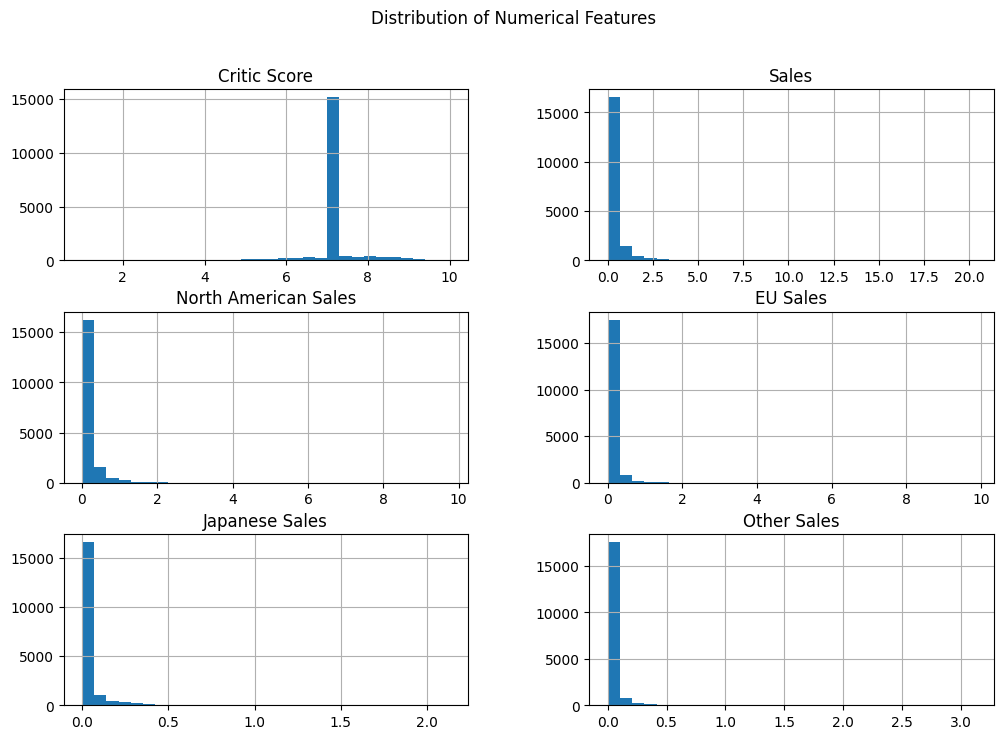

In [56]:
# Histogram of numerical columns

df[["Critic Score","Sales","North American Sales",
    "EU Sales","Japanese Sales","Other Sales"]].hist(figsize=(12,8), bins=30)
plt.suptitle("Distribution of Numerical Features")
plt.show()

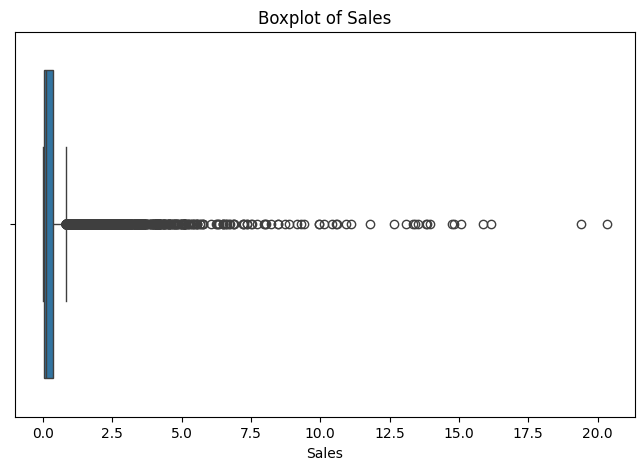

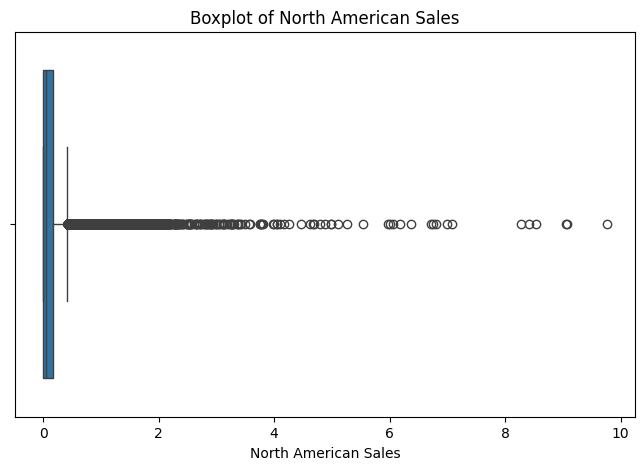

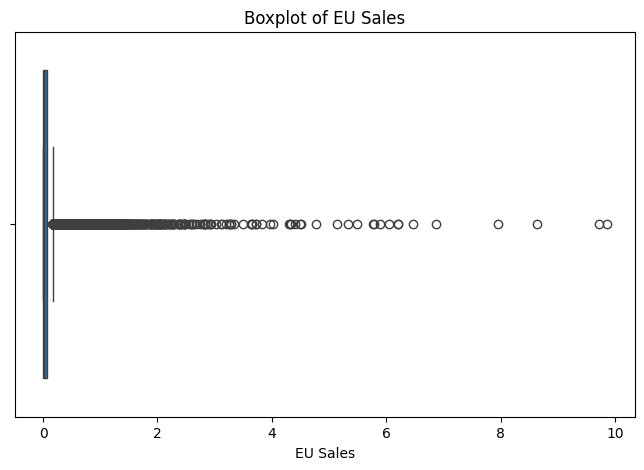

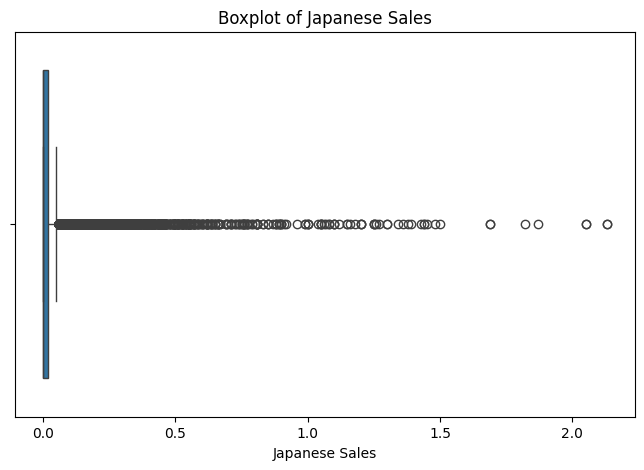

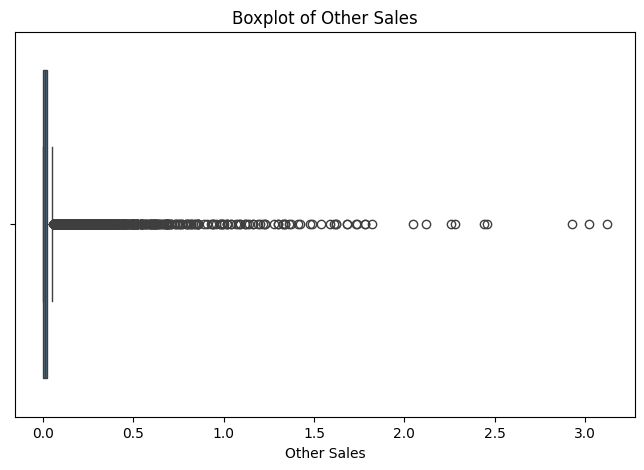

In [57]:
#Boxplot For Numerical Values 

for col in ["Sales","North American Sales","EU Sales","Japanese Sales","Other Sales"]:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

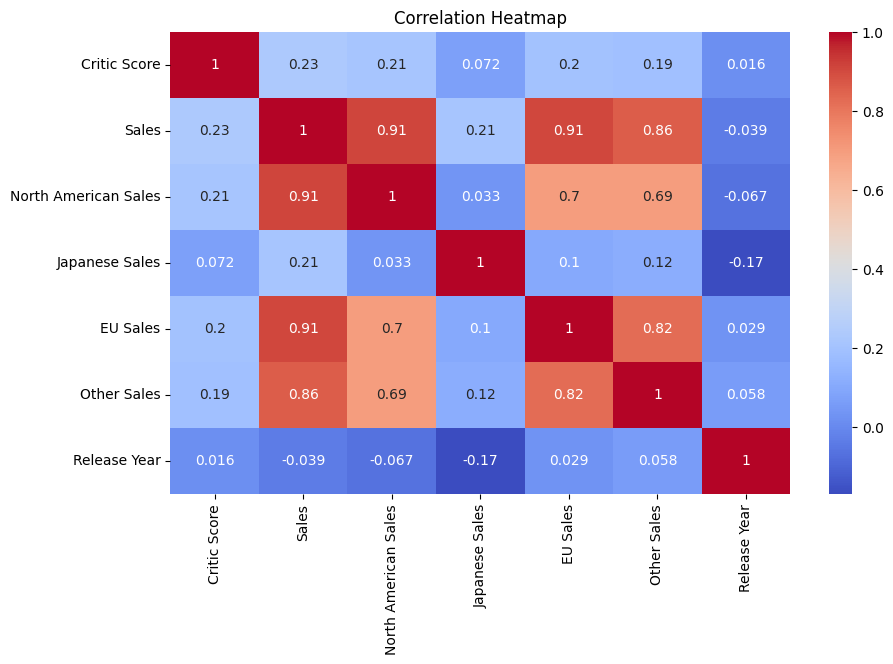

In [58]:
# Correlation heatmap (numerical columns)

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

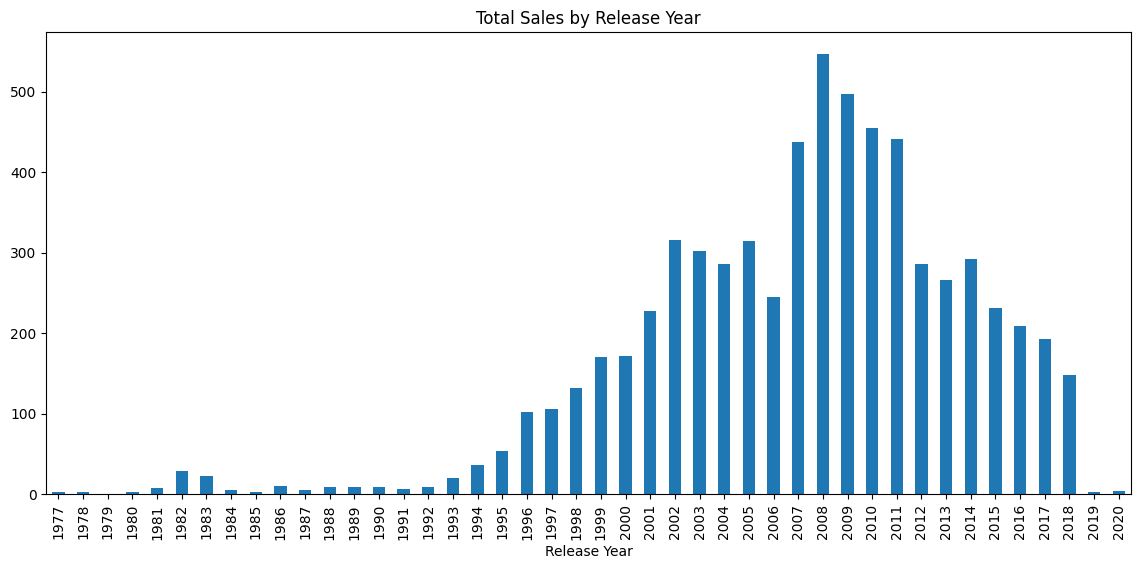

In [59]:
# Sales by release year

df.groupby("Release Year")["Sales"].sum().plot(kind="bar", figsize=(14,6))
plt.title("Total Sales by Release Year")
plt.show()

In [60]:
df.to_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/cleaned/1. Cleaning & Missing Values/Cleaning & Missing Values.csv", index=False)